In [1]:
import fastf1
import pandas
import matplotlib.pyplot as plt
import numpy as np

In [131]:

session = fastf1.get_session(2025, 'Abu Dhabi', 'R')
session.load()

driver_code = 'PIA'

driver_laps = session.laps.pick_driver(driver_code)

print(driver_laps[['LapNumber', 'LapTime']])

river_laps = session.laps.pick_driver(driver_code)

# Get lap times as a list of timedeltas
lap_times = driver_laps['LapTime'].dropna().to_list()

# Optional: convert timedeltas to seconds
lap_times_seconds = [lt.total_seconds() for lt in lap_times]

print(lap_times_seconds)

core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


     LapNumber                LapTime
58         1.0 0 days 00:01:32.906000
59         2.0 0 days 00:01:29.814000
60         3.0 0 days 00:01:29.525000
61         4.0 0 days 00:01:29.926000
62         5.0 0 days 00:01:29.758000
63         6.0 0 days 00:01:29.787000
64         7.0 0 days 00:01:29.568000
65         8.0 0 days 00:01:29.496000
66         9.0 0 days 00:01:29.571000
67        10.0 0 days 00:01:29.468000
68        11.0 0 days 00:01:29.466000
69        12.0 0 days 00:01:29.492000
70        13.0 0 days 00:01:29.261000
71        14.0 0 days 00:01:29.625000
72        15.0 0 days 00:01:29.536000
73        16.0 0 days 00:01:29.681000
74        17.0 0 days 00:01:29.535000
75        18.0 0 days 00:01:29.557000
76        19.0 0 days 00:01:29.598000
77        20.0 0 days 00:01:29.892000
78        21.0 0 days 00:01:29.584000
79        22.0 0 days 00:01:29.503000
80        23.0 0 days 00:01:29.515000
81        24.0 0 days 00:01:29.435000
82        25.0 0 days 00:01:29.261000
83        26

/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3067: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3067: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [133]:
# Print results
for n in lap_times_seconds:
    print(n)

92.906
89.814
89.525
89.926
89.758
89.787
89.568
89.496
89.571
89.468
89.466
89.492
89.261
89.625
89.536
89.681
89.535
89.557
89.598
89.892
89.584
89.503
89.515
89.435
89.261
89.492
89.299
89.004
88.927
89.119
88.983
89.001
89.002
89.313
89.177
89.009
89.126
89.106
89.26
89.388
92.723
108.367
87.369
86.765
87.392
86.965
86.994
87.022
87.112
87.039
87.312
87.498
87.527
87.744
87.79
87.998
88.406
88.074


In [135]:
fuel_burn_per_lap = 110/58  # kg/lap
time_per_10kg = 0.3      # seconds
# Fuel correction calculation
time_per_kg = time_per_10kg / 10
fuelLapCorrections = []
current_fuel = fuel_burn_per_lap * totalLapNumber

for lap in range(totalLapNumber):
    fuelLapCorrections.append(current_fuel * time_per_kg)
    current_fuel -= fuel_burn_per_lap

In [137]:
fuel_burn_per_lap = 110/58         # kg per lap
time_per_10kg = 0.3              # seconds per 10 kg fuel
totalLapNumber = 58
pitLap = 41

def get_fuel_corrections(start_fuel, total_laps):
    """Generates fuel corrections starting from specified fuel load"""
    corrections = []
    current_fuel = start_fuel
    for _ in range(total_laps):
        corrections.append(current_fuel * (time_per_10kg / 10))
        current_fuel -= fuel_burn_per_lap
    return corrections

def apply_fuel_correction(actual_laps, start_lap, start_fuel):
    """Apply fuel correction to actual lap times"""
    corrections = get_fuel_corrections(start_fuel, len(actual_laps))
    corrected_laps = []
    for i, lap_time in enumerate(actual_laps):
        fuel_effect = corrections[i]  # seconds to subtract
        corrected_lap = lap_time - fuel_effect
        corrected_laps.append(corrected_lap)
    return corrected_laps


first_stint = [92.906, 89.814, 89.525, 89.926, 89.758, 89.787, 89.568, 89.496, 89.571, 89.468, 89.466, 89.492, 89.261, 89.625, 89.536, 89.681, 89.535, 89.557, 89.598, 89.892, 89.584, 89.503, 89.515, 89.435, 89.261, 89.492, 89.299, 89.004, 88.927, 89.119, 88.983, 89.001, 89.002, 89.313, 89.177, 89.009, 89.126, 89.106, 89.26, 89.388, 92.723]
second_stint = [108.367, 87.369, 86.765, 87.392, 86.965, 86.994, 87.022, 87.112, 87.039, 87.312, 87.498, 87.527, 87.744, 87.79, 87.998, 88.406, 88.074]

# Compute total starting fuel
full_fuel = fuel_burn_per_lap * totalLapNumber

first_stint_clean = first_stint[:pitLap-1]
second_stint_clean = second_stint[1:]

# Apply corrections to both stints
first_stint_corrected = apply_fuel_correction(first_stint_clean, 1, full_fuel)
second_stint_corrected = apply_fuel_correction(second_stint_clean, pitLap + 1, full_fuel)


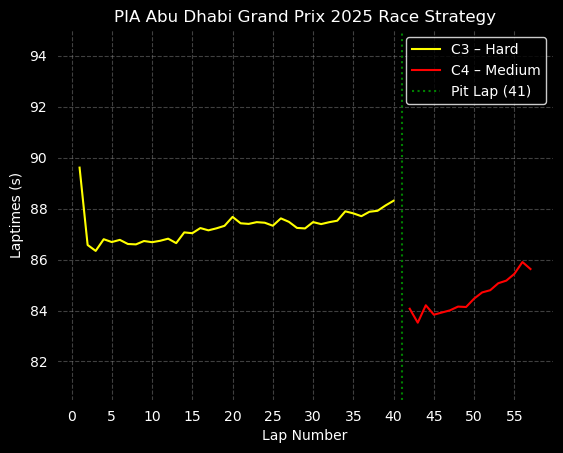

In [139]:
# Plotting
fig, ax = plt.subplots()
fig.patch.set_facecolor('black')
ax.set_facecolor('black')


# Plot data
laps = list(range(1, totalLapNumber + 1))
plt.plot(laps[:len(first_stint_clean)], first_stint_corrected, color='yellow', label='C3 – Hard')
plt.plot(laps[pitLap:pitLap + len(second_stint_clean)], second_stint_corrected, color='red', label='C4 – Medium')
plt.axvline(x=pitLap, color='green', linestyle=':', label=f'Pit Lap ({pitLap})')

# Formatting
plt.title("PIA Abu Dhabi Grand Prix 2025 Race Strategy", color='white')
plt.xlabel("Lap Number", color='white')
plt.ylabel("Laptimes (s)", color='white')
plt.ylim(80.5, 95)
plt.xticks(np.arange(0, totalLapNumber + 1, 5), color='white')
plt.yticks(color='white')
plt.grid(color='gray', linestyle='--', alpha=0.5)
plt.legend(facecolor='black', edgecolor='white', labelcolor='white')

plt.show()

In [141]:

session = fastf1.get_session(2025, 'Abu Dhabi', 'R')
session.load()

driver_code = 'HAM'

driver_laps = session.laps.pick_driver(driver_code)

print(driver_laps[['LapNumber', 'LapTime']])

river_laps = session.laps.pick_driver(driver_code)

# Get lap times as a list of timedeltas
lap_times = driver_laps['LapTime'].dropna().to_list()

# Optional: convert timedeltas to seconds
lap_times_seconds = [lt.total_seconds() for lt in lap_times]

print(lap_times_seconds)

core           INFO 	Loading data for Abu Dhabi Grand Prix - Race [v3.5.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '63', '14', '31', '44', '27', '18', '5', '87', '55', '22', '12', '23', '6', '30', '10', '43']


     LapNumber                LapTime
406        1.0 0 days 00:01:39.335000
407        2.0 0 days 00:01:30.853000
408        3.0 0 days 00:01:30.113000
409        4.0 0 days 00:01:30.883000
410        5.0 0 days 00:01:30.229000
411        6.0 0 days 00:01:30.254000
412        7.0 0 days 00:01:30.539000
413        8.0 0 days 00:01:32.249000
414        9.0 0 days 00:01:48.500000
415       10.0 0 days 00:01:28.517000
416       11.0 0 days 00:01:29.022000
417       12.0 0 days 00:01:29.598000
418       13.0 0 days 00:01:29.473000
419       14.0 0 days 00:01:29.276000
420       15.0 0 days 00:01:29.574000
421       16.0 0 days 00:01:29.461000
422       17.0 0 days 00:01:29.299000
423       18.0 0 days 00:01:29.700000
424       19.0 0 days 00:01:29.841000
425       20.0 0 days 00:01:30.736000
426       21.0 0 days 00:01:31.793000
427       22.0 0 days 00:01:30.535000
428       23.0 0 days 00:01:30.076000
429       24.0 0 days 00:01:29.866000
430       25.0 0 days 00:01:29.810000
431       26

/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3067: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
/opt/anaconda3/lib/python3.12/site-packages/fastf1/core.py:3067: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


In [143]:
fuel_burn_per_lap = 110/58        # kg per lap
time_per_10kg = 0.3              # seconds per 10 kg fuel
totalLapNumber = 58
pitLap1 = 8
pitLap2 = 31

def get_fuel_corrections(start_fuel, total_laps):
    """Generates fuel corrections starting from specified fuel load"""
    corrections = []
    current_fuel = start_fuel
    for _ in range(total_laps):
        corrections.append(current_fuel * (time_per_10kg / 10))
        current_fuel -= fuel_burn_per_lap
    return corrections

def apply_fuel_correction(actual_laps, start_lap, start_fuel):
    """Apply fuel correction to actual lap times"""
    corrections = get_fuel_corrections(start_fuel, len(actual_laps))
    corrected_laps = []
    for i, lap_time in enumerate(actual_laps):
        fuel_effect = corrections[i]  # seconds to subtract
        corrected_lap = lap_time - fuel_effect
        corrected_laps.append(corrected_lap)
    return corrected_laps


first_stint = [99.335, 90.853, 90.113, 90.883, 90.229, 90.254, 90.539, 92.249]
second_stint = [108.5, 88.517, 89.022, 89.598, 89.473, 89.276, 89.574, 89.461, 89.299, 89.7, 89.841, 90.736, 91.793, 90.535, 90.076, 89.866, 89.81, 89.644, 90.144, 89.918, 89.785, 89.88, 91.397]
third_stint = [108.714, 89.051, 88.794, 88.514, 88.094, 88.549, 88.141, 88.528, 89.048, 88.693, 88.873, 88.464, 88.949, 88.758, 89.24, 88.997, 88.979, 89.186, 88.978, 88.937, 89.625, 89.044, 88.731, 88.796, 89.623, 89.022, 89.511]

# Compute total starting fuel
full_fuel = fuel_burn_per_lap * totalLapNumber

first_stint_clean = first_stint[:pitLap1-1]
second_stint_clean = second_stint[1:pitLap2-1]
third_stint_clean = third_stint[1:]

# Apply corrections to both stints
first_stint_corrected = apply_fuel_correction(first_stint_clean, 1, full_fuel)
second_stint_corrected = apply_fuel_correction(second_stint_clean, pitLap1 + 1, full_fuel)
third_stint_corrected = apply_fuel_correction(third_stint_clean, pitLap2 + 1, full_fuel)
            

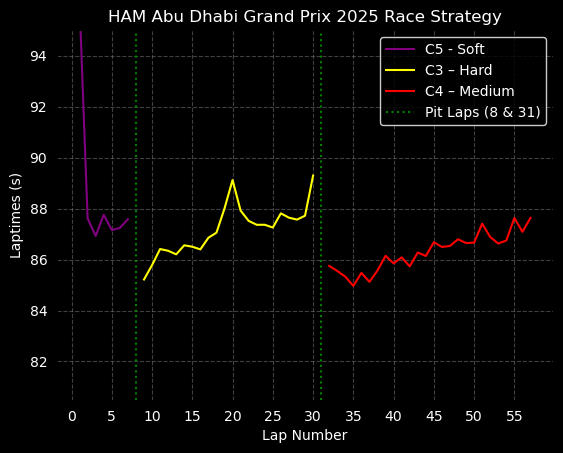

In [145]:
# Plotting
fig, ax = plt.subplots()
fig.patch.set_facecolor('black')
ax.set_facecolor('black')


# Plot data
laps = list(range(1, totalLapNumber + 1))
plt.plot(laps[:len(first_stint_clean)], first_stint_corrected, color='purple', label='C5 - Soft')
plt.plot(laps[pitLap1:pitLap1 + len(second_stint_clean)], second_stint_corrected, color='yellow', label='C3 – Hard')
plt.plot(laps[pitLap2:pitLap2 + len(third_stint_clean)], third_stint_corrected, color='red', label='C4 – Medium')
plt.axvline(x=pitLap1, color='green', linestyle=':', label=f'Pit Laps ({pitLap1} & {pitLap2})')
plt.axvline(x=pitLap2, color='green', linestyle=':')

# Formatting
plt.title("HAM Abu Dhabi Grand Prix 2025 Race Strategy", color='white')
plt.xlabel("Lap Number", color='white')
plt.ylabel("Laptimes (s)", color='white')
plt.ylim(80.5, 95)
plt.xticks(np.arange(0, totalLapNumber + 1, 5), color='white')
plt.yticks(color='white')
plt.grid(color='gray', linestyle='--', alpha=0.5)
plt.legend(facecolor='black', edgecolor='white', labelcolor='white')

plt.show()